This is the watch hours of each users who typed at least 2 times in a single stream min 5min period

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from collections import defaultdict
import numpy as np
import pytz
import re

In [2]:
# Read the list of filenames from the configuration file
with open('../file_list.txt', 'r', encoding='utf-8') as config_file:
    file_names = config_file.read().splitlines()

# Regex pattern to match the data format
pattern = r'\[(.*?)\] (.*?): (.*)'

# Initialize an empty list to store parsed data
datalist = []
stream_count = 0
# Iterate over each specified file
for file in file_names:
    full_path = f"../data/{file}"
    with open(full_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines:
            match = re.match(pattern, line)
            if match:
                date, user, message = match.groups()
                datalist.append([date, user, message,stream_count])
    stream_count = stream_count + 1

# Create a DataFrame from the parsed data
data = pd.DataFrame(datalist, columns=["date", "user", "message","stream"])
data['date'] = pd.to_datetime(data['date'])



In [3]:
data["user"] = data["user"].replace("Banties1g", "banties_x")
data["user"] = data["user"].replace("banties1g", "banties_x")
data["user"] = data["user"].replace("chili_poe", "chili_con_bacon")
data["user"] = data["user"].replace("CHILI_POE", "chili_con_bacon")
data["user"] = data["user"].replace("Chili_poe", "chili_con_bacon")
data["user"] = data["user"].replace("chili_conbacon", "chili_con_bacon")
data["user"] = data["user"].replace("Wirelesss_", "W1r3lesss")
data["user"] = data["user"].replace("treklul", "trek44_")
data["user"] = data["user"].replace("ttrek_", "trek44_")
data["user"] = data["user"].replace("trek_x", "trek44_")
data["user"] = data["user"].replace("TriplesingleJ", "TripleSingleJames")
data["user"] = data["user"].replace("uwu_cougar", "uuccugr")
data["user"] = data["user"].replace("uuccugr_","uuccugr")
data["user"] = data["user"].replace("StanIV4_", "stan_iv4")
data["user"] = data["user"].replace("Muuskie2", "Muuskie")
data["user"] = data["user"].replace("nishad_more1311", "nishad13")
data["user"] = data["user"].replace("softarballt", "softarr")
data["user"] = data["user"].replace("softarballtt23", "softarr")
data["user"] = data["user"].replace("lajosbarnabas", "lajoss__")
data["user"] = data["user"].replace("Bonkwiththefunk", "bonk67")
data["user"] = data["user"].replace("qfishyy11", "bonk67")
data["user"] = data["user"].replace("schiken44", "aransamus64")

In [4]:
# Get all unique usernames
unique_users = data['user'].unique()

# Create a mapping from lowercase username to all variants

user_variants = defaultdict(set)
for user in unique_users:
    user_variants[user.lower()].add(user)

# Find usernames with different capitalization
duplicate_users = {k: v for k, v in user_variants.items() if len(v) > 1}

In [5]:
# Create a mapping from all variants to the canonical (sorted first) variant
variant_map = {}
for variants in duplicate_users.values():
    sorted_variants = sorted(variants)
    canonical = sorted_variants[0]
    for v in variants:
        variant_map[v] = canonical

# Replace usernames in 'user' column
data['user'] = data['user'].apply(lambda u: variant_map.get(u, u))

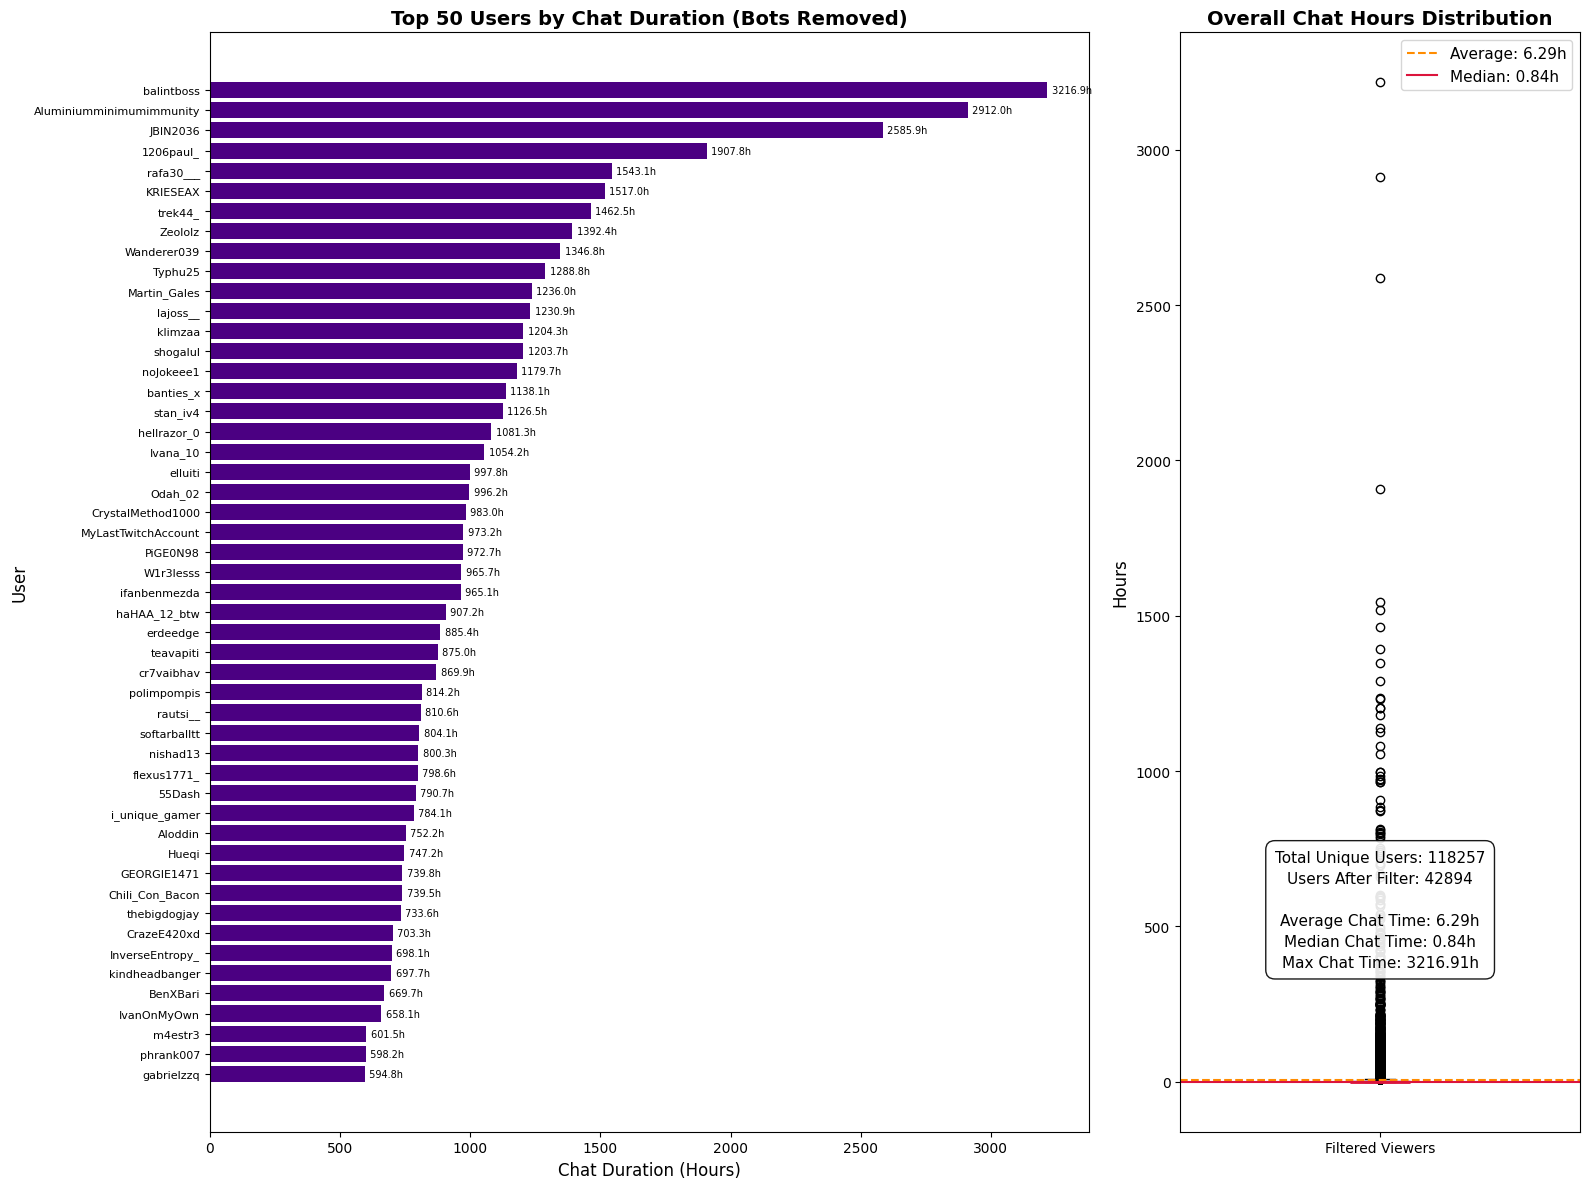

In [6]:
# 2. Exclude designated chat bots (case-insensitive checking can be added if needed)
bots = ['StreamElements', 'Fossabot', 'Nightbot', 'streamelements', 'fossabot', 'nightbot']
data_no_bots = data[~data['user'].isin(bots)].copy()

# 3. Aggregate first/last messages per stream per user
grouped = data_no_bots.groupby(['stream', 'user']).agg(
    first_msg=('date', 'min'),
    last_msg=('date', 'max'),
    msg_count=('message', 'count')
).reset_index()
grouped['duration'] = grouped['last_msg'] - grouped['first_msg']

# 4. Filter criteria (>= 2 messages and >= 5 minutes active window)
filtered = grouped[(grouped['msg_count'] >= 2) & (grouped['duration'] >= pd.Timedelta(minutes=5))].copy()

total_users_chatted = data_no_bots['user'].nunique()
users_after_filtering = filtered['user'].nunique()

# 5. Sum active hours across streams
user_chattime = filtered.groupby('user')['duration'].sum().reset_index()
user_chattime['duration_hours'] = user_chattime['duration'].dt.total_seconds() / 3600.0

# Sort and extract Top 50
user_chattime_sorted = user_chattime.sort_values(by='duration_hours', ascending=False)
top_50_users = user_chattime_sorted.head(50)

# Calculate descriptive statistics
avg_hours = user_chattime['duration_hours'].mean()
median_hours = user_chattime['duration_hours'].median()

# 6. Generate the Dual-Panel Visual Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [2.2, 1]})

# Left Panel: Top 50 Users Ranking
top_50_reversed = top_50_users.iloc[::-1]
bars = ax1.barh(top_50_reversed['user'], top_50_reversed['duration_hours'], color='indigo')
ax1.set_title("Top 50 Users by Chat Duration (Bots Removed)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Chat Duration (Hours)", fontsize=12)
ax1.set_ylabel("User", fontsize=12)
ax1.tick_params(axis='y', labelsize=8)

for bar in bars:
    width = bar.get_width()
    ax1.annotate(f' {width:.1f}h',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(1, 0),
                textcoords="offset points",
                ha='left', va='center', fontsize=7)

# Right Panel: Core Distribution & Averages
ax2.boxplot(user_chattime['duration_hours'], patch_artist=True,
            boxprops=dict(facecolor='#E6E6FA', color='indigo'),
            medianprops=dict(color='crimson', linewidth=2))

ax2.axhline(avg_hours, color='darkorange', linestyle='--', linewidth=1.5, label=f'Average: {avg_hours:.2f}h')
ax2.axhline(median_hours, color='crimson', linestyle='-', linewidth=1.5, label=f'Median: {median_hours:.2f}h')

ax2.set_title("Overall Chat Hours Distribution", fontsize=14, fontweight='bold')
ax2.set_ylabel("Hours", fontsize=12)
ax2.set_xticklabels(['Filtered Viewers'])
ax2.legend(loc='upper right', fontsize=11)

# Overlay Stats Text Block
stats_text = (
    f"Total Unique Users: {total_users_chatted}\n"
    f"Users After Filter: {users_after_filtering}\n\n"
    f"Average Chat Time: {avg_hours:.2f}h\n"
    f"Median Chat Time: {median_hours:.2f}h\n"
    f"Max Chat Time: {user_chattime['duration_hours'].max():.2f}h"
)
ax2.text(0.5, 0.15, stats_text, transform=ax2.transAxes, 
         bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.6'),
         fontsize=11, ha='center', linespacing=1.5)

plt.tight_layout()
plt.show()

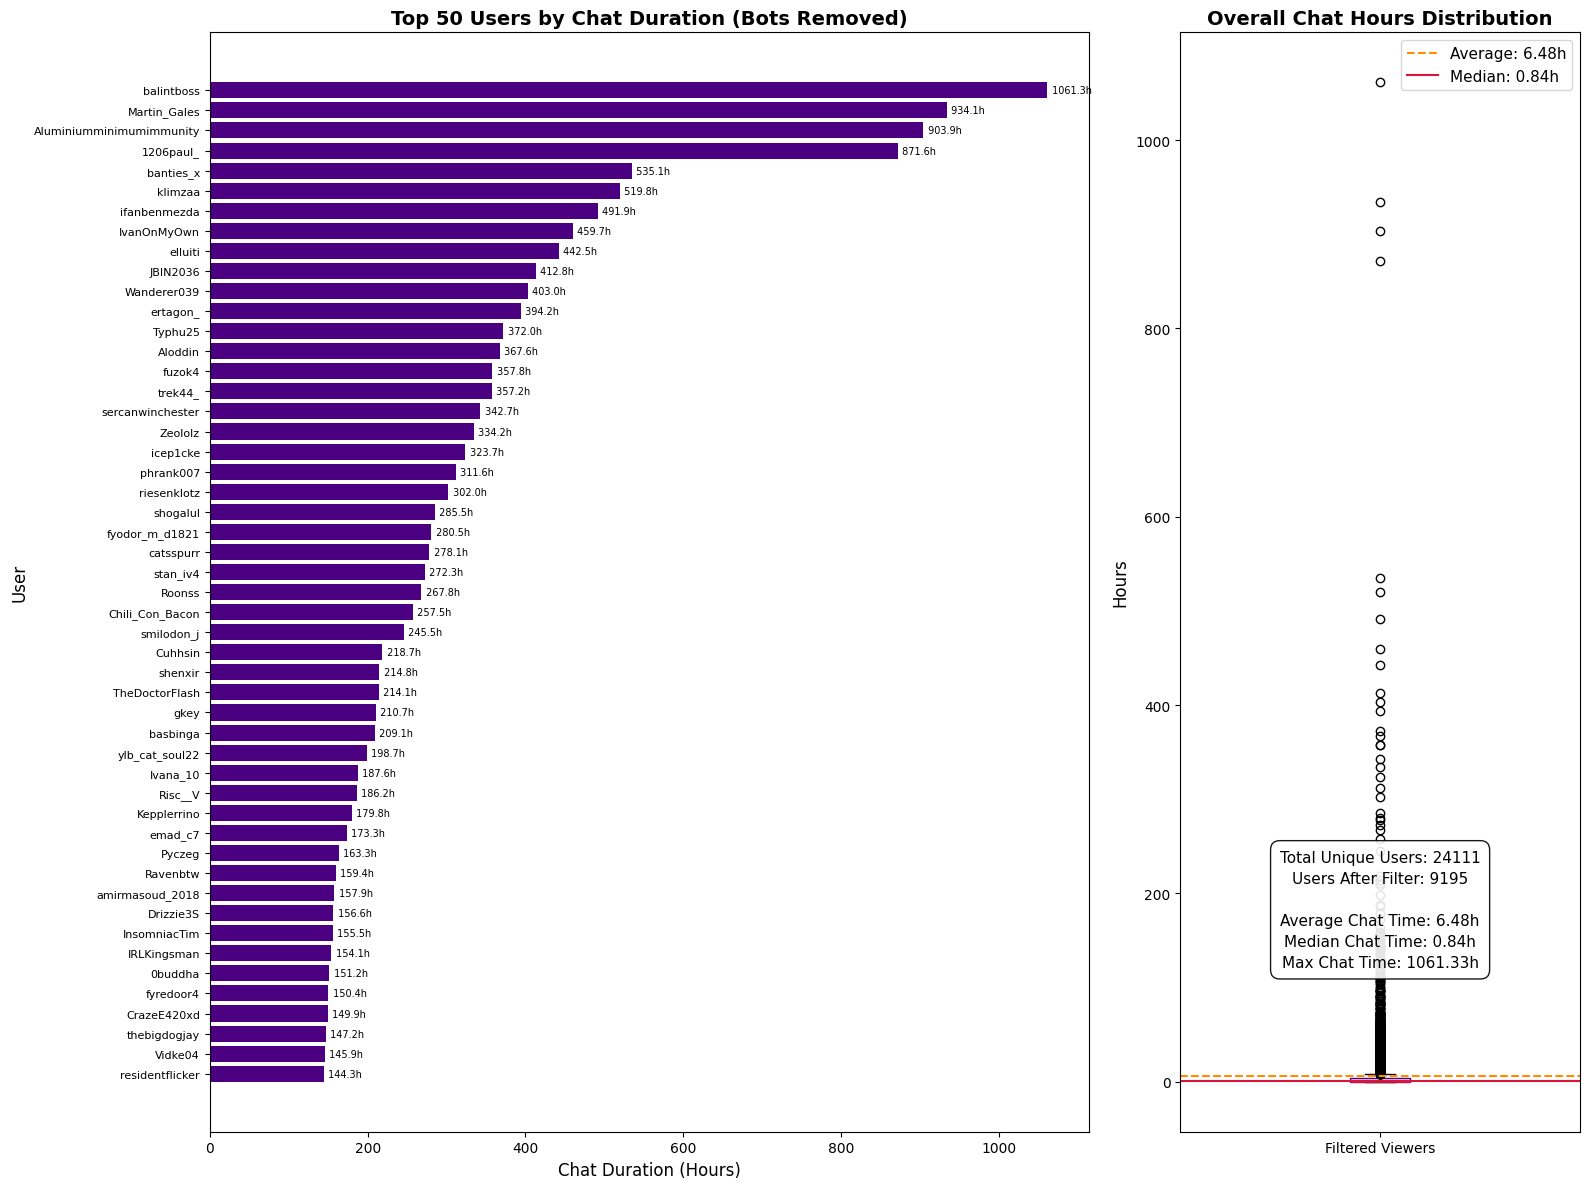

In [7]:
data_2024 = data[data['date'].dt.year == 2024]

data_no_bots = data_2024[~data_2024['user'].isin(bots)].copy()

# 3. Aggregate first/last messages per stream per user
grouped = data_no_bots.groupby(['stream', 'user']).agg(
    first_msg=('date', 'min'),
    last_msg=('date', 'max'),
    msg_count=('message', 'count')
).reset_index()
grouped['duration'] = grouped['last_msg'] - grouped['first_msg']

# 4. Filter criteria (>= 2 messages and >= 5 minutes active window)
filtered = grouped[(grouped['msg_count'] >= 2) & (grouped['duration'] >= pd.Timedelta(minutes=5))].copy()

total_users_chatted = data_no_bots['user'].nunique()
users_after_filtering = filtered['user'].nunique()

# 5. Sum active hours across streams
user_chattime = filtered.groupby('user')['duration'].sum().reset_index()
user_chattime['duration_hours'] = user_chattime['duration'].dt.total_seconds() / 3600.0

# Sort and extract Top 50
user_chattime_sorted = user_chattime.sort_values(by='duration_hours', ascending=False)
top_50_users = user_chattime_sorted.head(50)

# Calculate descriptive statistics
avg_hours = user_chattime['duration_hours'].mean()
median_hours = user_chattime['duration_hours'].median()

# 6. Generate the Dual-Panel Visual Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [2.2, 1]})

# Left Panel: Top 50 Users Ranking
top_50_reversed = top_50_users.iloc[::-1]
bars = ax1.barh(top_50_reversed['user'], top_50_reversed['duration_hours'], color='indigo')
ax1.set_title("Top 50 Users by Chat Duration (Bots Removed)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Chat Duration (Hours)", fontsize=12)
ax1.set_ylabel("User", fontsize=12)
ax1.tick_params(axis='y', labelsize=8)

for bar in bars:
    width = bar.get_width()
    ax1.annotate(f' {width:.1f}h',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(1, 0),
                textcoords="offset points",
                ha='left', va='center', fontsize=7)

# Right Panel: Core Distribution & Averages
ax2.boxplot(user_chattime['duration_hours'], patch_artist=True,
            boxprops=dict(facecolor='#E6E6FA', color='indigo'),
            medianprops=dict(color='crimson', linewidth=2))

ax2.axhline(avg_hours, color='darkorange', linestyle='--', linewidth=1.5, label=f'Average: {avg_hours:.2f}h')
ax2.axhline(median_hours, color='crimson', linestyle='-', linewidth=1.5, label=f'Median: {median_hours:.2f}h')

ax2.set_title("Overall Chat Hours Distribution", fontsize=14, fontweight='bold')
ax2.set_ylabel("Hours", fontsize=12)
ax2.set_xticklabels(['Filtered Viewers'])
ax2.legend(loc='upper right', fontsize=11)

# Overlay Stats Text Block
stats_text = (
    f"Total Unique Users: {total_users_chatted}\n"
    f"Users After Filter: {users_after_filtering}\n\n"
    f"Average Chat Time: {avg_hours:.2f}h\n"
    f"Median Chat Time: {median_hours:.2f}h\n"
    f"Max Chat Time: {user_chattime['duration_hours'].max():.2f}h"
)
ax2.text(0.5, 0.15, stats_text, transform=ax2.transAxes, 
         bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.6'),
         fontsize=11, ha='center', linespacing=1.5)

plt.tight_layout()
plt.show()

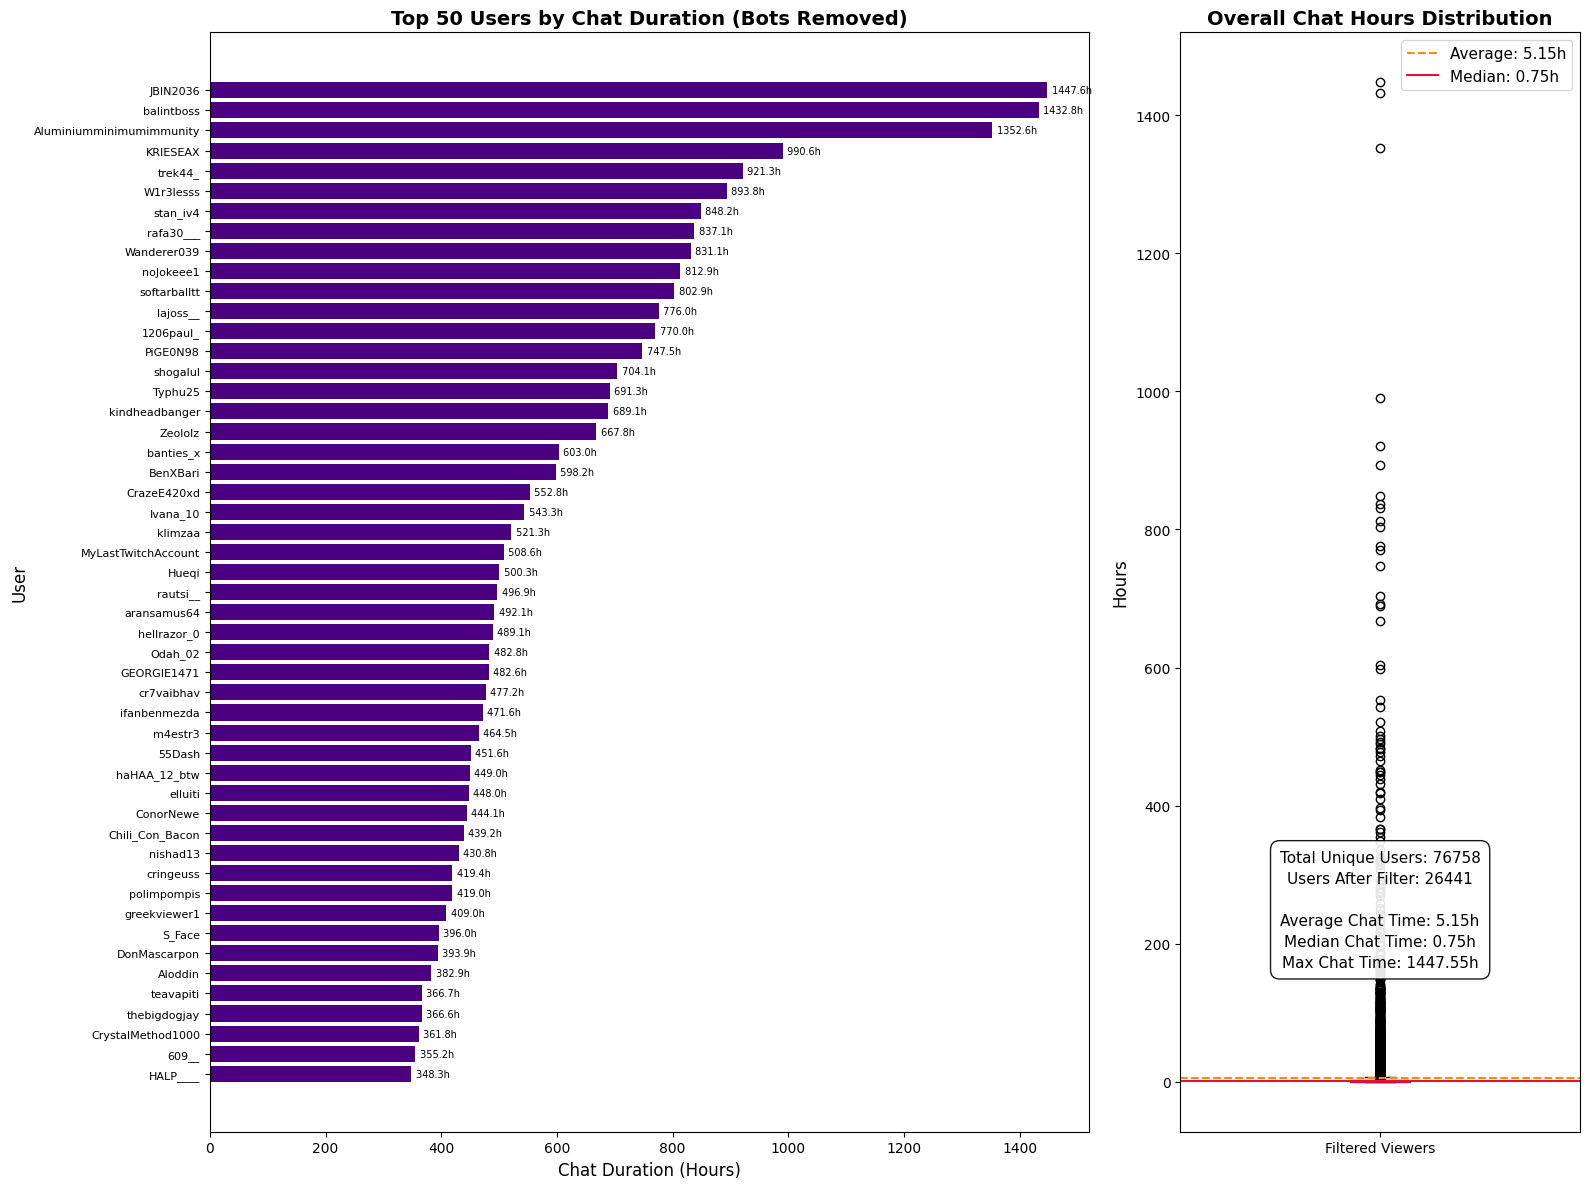

In [8]:
data_2025 = data[data['date'].dt.year == 2025]

data_no_bots = data_2025[~data_2025['user'].isin(bots)].copy()

# 3. Aggregate first/last messages per stream per user
grouped = data_no_bots.groupby(['stream', 'user']).agg(
    first_msg=('date', 'min'),
    last_msg=('date', 'max'),
    msg_count=('message', 'count')
).reset_index()
grouped['duration'] = grouped['last_msg'] - grouped['first_msg']

# 4. Filter criteria (>= 2 messages and >= 5 minutes active window)
filtered = grouped[(grouped['msg_count'] >= 2) & (grouped['duration'] >= pd.Timedelta(minutes=5))].copy()

total_users_chatted = data_no_bots['user'].nunique()
users_after_filtering = filtered['user'].nunique()

# 5. Sum active hours across streams
user_chattime = filtered.groupby('user')['duration'].sum().reset_index()
user_chattime['duration_hours'] = user_chattime['duration'].dt.total_seconds() / 3600.0

# Sort and extract Top 50
user_chattime_sorted = user_chattime.sort_values(by='duration_hours', ascending=False)
top_50_users = user_chattime_sorted.head(50)

# Calculate descriptive statistics
avg_hours = user_chattime['duration_hours'].mean()
median_hours = user_chattime['duration_hours'].median()

# 6. Generate the Dual-Panel Visual Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [2.2, 1]})

# Left Panel: Top 50 Users Ranking
top_50_reversed = top_50_users.iloc[::-1]
bars = ax1.barh(top_50_reversed['user'], top_50_reversed['duration_hours'], color='indigo')
ax1.set_title("Top 50 Users by Chat Duration (Bots Removed)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Chat Duration (Hours)", fontsize=12)
ax1.set_ylabel("User", fontsize=12)
ax1.tick_params(axis='y', labelsize=8)

for bar in bars:
    width = bar.get_width()
    ax1.annotate(f' {width:.1f}h',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(1, 0),
                textcoords="offset points",
                ha='left', va='center', fontsize=7)

# Right Panel: Core Distribution & Averages
ax2.boxplot(user_chattime['duration_hours'], patch_artist=True,
            boxprops=dict(facecolor='#E6E6FA', color='indigo'),
            medianprops=dict(color='crimson', linewidth=2))

ax2.axhline(avg_hours, color='darkorange', linestyle='--', linewidth=1.5, label=f'Average: {avg_hours:.2f}h')
ax2.axhline(median_hours, color='crimson', linestyle='-', linewidth=1.5, label=f'Median: {median_hours:.2f}h')

ax2.set_title("Overall Chat Hours Distribution", fontsize=14, fontweight='bold')
ax2.set_ylabel("Hours", fontsize=12)
ax2.set_xticklabels(['Filtered Viewers'])
ax2.legend(loc='upper right', fontsize=11)

# Overlay Stats Text Block
stats_text = (
    f"Total Unique Users: {total_users_chatted}\n"
    f"Users After Filter: {users_after_filtering}\n\n"
    f"Average Chat Time: {avg_hours:.2f}h\n"
    f"Median Chat Time: {median_hours:.2f}h\n"
    f"Max Chat Time: {user_chattime['duration_hours'].max():.2f}h"
)
ax2.text(0.5, 0.15, stats_text, transform=ax2.transAxes, 
         bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.6'),
         fontsize=11, ha='center', linespacing=1.5)

plt.tight_layout()
plt.show()

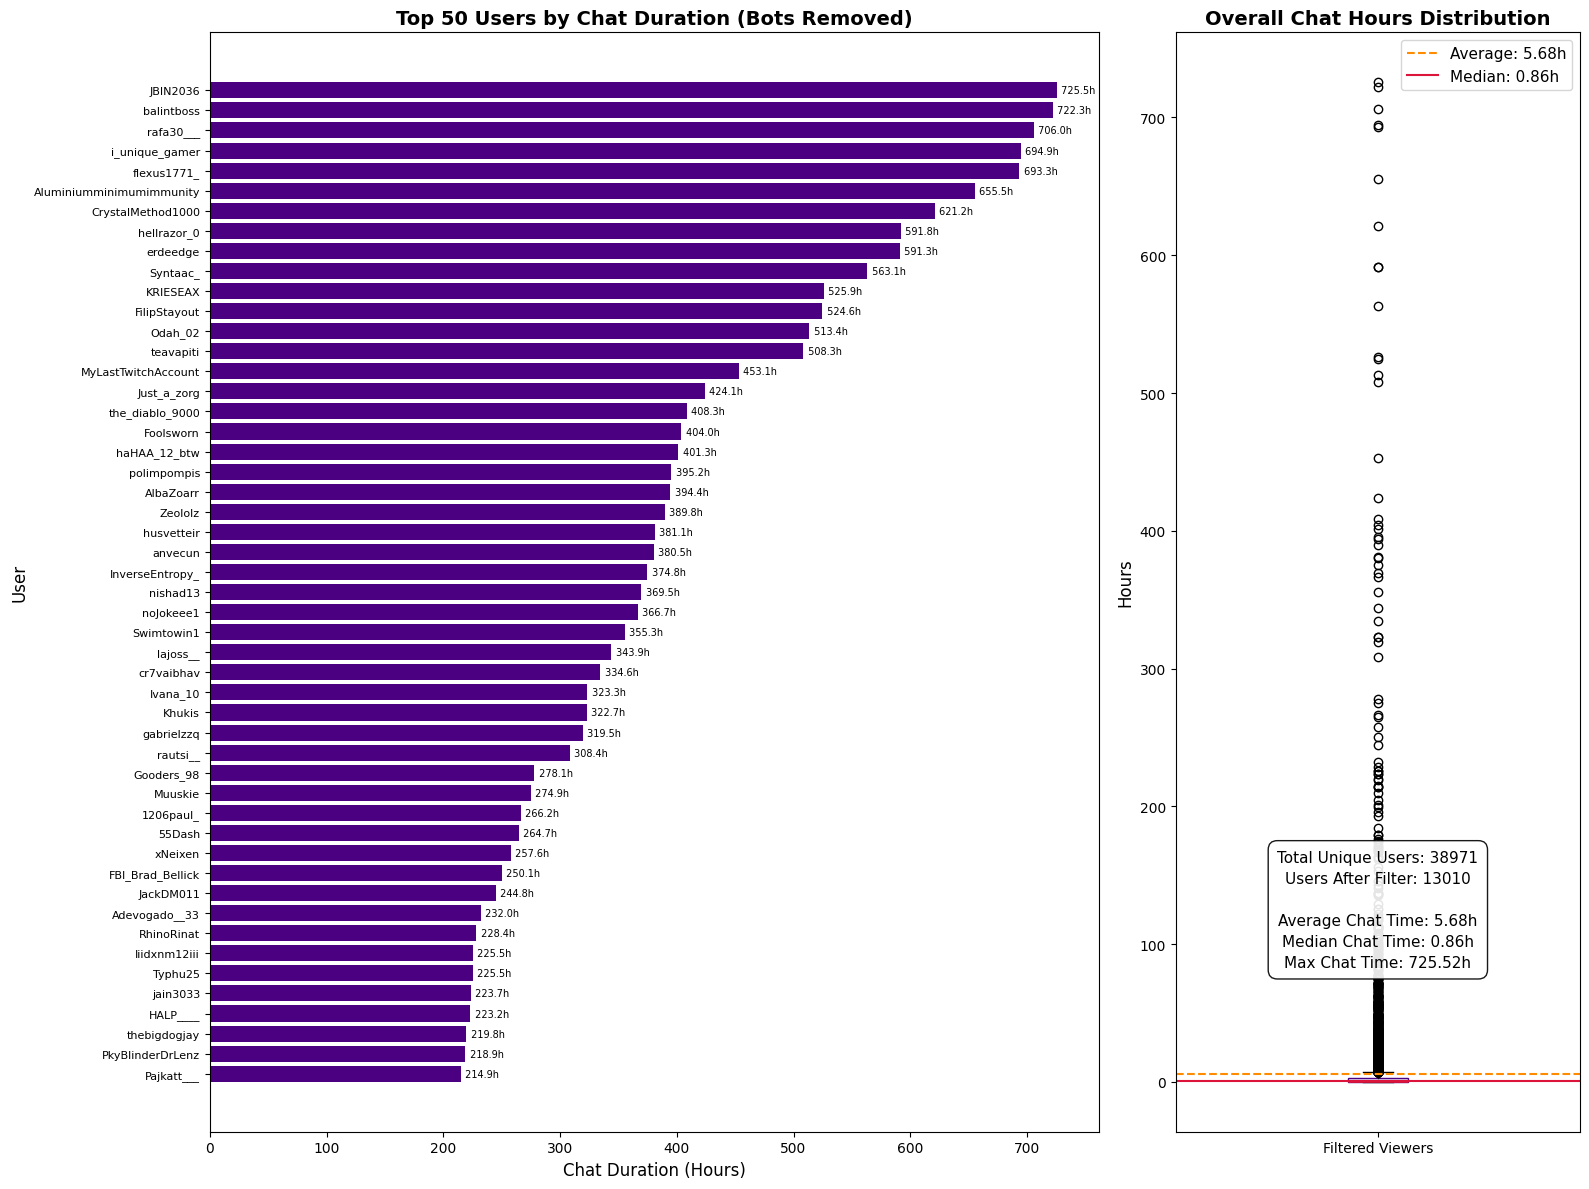

In [9]:
data_2026 = data[data['date'].dt.year == 2026]

data_no_bots = data_2026[~data_2026['user'].isin(bots)].copy()

# 3. Aggregate first/last messages per stream per user
grouped = data_no_bots.groupby(['stream', 'user']).agg(
    first_msg=('date', 'min'),
    last_msg=('date', 'max'),
    msg_count=('message', 'count')
).reset_index()
grouped['duration'] = grouped['last_msg'] - grouped['first_msg']

# 4. Filter criteria (>= 2 messages and >= 5 minutes active window)
filtered = grouped[(grouped['msg_count'] >= 2) & (grouped['duration'] >= pd.Timedelta(minutes=5))].copy()

total_users_chatted = data_no_bots['user'].nunique()
users_after_filtering = filtered['user'].nunique()

# 5. Sum active hours across streams
user_chattime = filtered.groupby('user')['duration'].sum().reset_index()
user_chattime['duration_hours'] = user_chattime['duration'].dt.total_seconds() / 3600.0

# Sort and extract Top 50
user_chattime_sorted = user_chattime.sort_values(by='duration_hours', ascending=False)
top_50_users = user_chattime_sorted.head(50)

# Calculate descriptive statistics
avg_hours = user_chattime['duration_hours'].mean()
median_hours = user_chattime['duration_hours'].median()

# 6. Generate the Dual-Panel Visual Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [2.2, 1]})

# Left Panel: Top 50 Users Ranking
top_50_reversed = top_50_users.iloc[::-1]
bars = ax1.barh(top_50_reversed['user'], top_50_reversed['duration_hours'], color='indigo')
ax1.set_title("Top 50 Users by Chat Duration (Bots Removed)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Chat Duration (Hours)", fontsize=12)
ax1.set_ylabel("User", fontsize=12)
ax1.tick_params(axis='y', labelsize=8)

for bar in bars:
    width = bar.get_width()
    ax1.annotate(f' {width:.1f}h',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(1, 0),
                textcoords="offset points",
                ha='left', va='center', fontsize=7)

# Right Panel: Core Distribution & Averages
ax2.boxplot(user_chattime['duration_hours'], patch_artist=True,
            boxprops=dict(facecolor='#E6E6FA', color='indigo'),
            medianprops=dict(color='crimson', linewidth=2))

ax2.axhline(avg_hours, color='darkorange', linestyle='--', linewidth=1.5, label=f'Average: {avg_hours:.2f}h')
ax2.axhline(median_hours, color='crimson', linestyle='-', linewidth=1.5, label=f'Median: {median_hours:.2f}h')

ax2.set_title("Overall Chat Hours Distribution", fontsize=14, fontweight='bold')
ax2.set_ylabel("Hours", fontsize=12)
ax2.set_xticklabels(['Filtered Viewers'])
ax2.legend(loc='upper right', fontsize=11)

# Overlay Stats Text Block
stats_text = (
    f"Total Unique Users: {total_users_chatted}\n"
    f"Users After Filter: {users_after_filtering}\n\n"
    f"Average Chat Time: {avg_hours:.2f}h\n"
    f"Median Chat Time: {median_hours:.2f}h\n"
    f"Max Chat Time: {user_chattime['duration_hours'].max():.2f}h"
)
ax2.text(0.5, 0.15, stats_text, transform=ax2.transAxes, 
         bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.6'),
         fontsize=11, ha='center', linespacing=1.5)

plt.tight_layout()
plt.show()